# Super Tic-Tac-Toe Benchmark (RLlib)

This notebook keeps the overall structure of the original benchmark, but:

- Uses **RLlib only**: `PPO`, `IMPALA`, `APPO`.
- Removes all Chinese text.
- Training schedule:
  - First **50%** of training: **deterministic placement** (`stochastic_moves=False`).
  - Last **50%** of training: **stochastic placement** (`stochastic_moves=True`, `accept_prob=0.5`).
  - Additionally, the **first 5 actions of every episode** are forced to be **random valid moves** (to avoid always training on exactly the same opening trajectory).
- Evaluation:
  - Evaluate under **deterministic** and **stochastic** environments separately.
- Plotting:
  - A **red dashed vertical line** marks the switch from deterministic to stochastic training in the **episode length** plot.


In [1]:
import sys
import subprocess
from importlib import metadata as md

def _pip(*args):
    cmd = [sys.executable, "-m", "pip", *args]
    print(">>", " ".join(cmd))
    subprocess.check_call(cmd)

def _ver(name: str):
    try:
        return md.version(name)
    except md.PackageNotFoundError:
        return None

np_ver = _ver("numpy")
print("NumPy version (metadata):", np_ver)
if np_ver is None or int(np_ver.split(".")[0]) >= 2:
    _pip("install", "-U", "--force-reinstall", "--no-cache-dir", "numpy<2")
    print("NumPy has been downgraded. Please restart the kernel and continue from the next cell.")
    raise SystemExit


NumPy version (metadata): 1.26.4


In [2]:
import os
os.environ.setdefault("TORCHDYNAMO_DISABLE", "1")
os.environ.setdefault("RAY_DISABLE_DASHBOARD", "1")
os.environ.setdefault("RAY_USAGE_STATS_ENABLED", "0")
os.environ.setdefault("RAY_DEDUP_LOGS", "0")

import time
import random
from typing import Dict, Optional, Tuple

import numpy as np
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn

from tqdm.auto import tqdm
import pandas as pd

import sys
import importlib.abc
import importlib.machinery

SEED = 42

ITERS = 1000
EVAL_EVERY = 50
EVAL_EPISODES = 250
FINAL_EVAL_EPISODES = 500

TRAIN_DET_FRAC = 0.5
OPENING_RANDOM_MOVES_TRAIN = 25
TRAIN_STOCH_ACCEPT_PROB = 0.5

EVAL_DET_ACCEPT_PROB = 1.0
EVAL_STOCH_ACCEPT_PROB = 0.5
OPENING_RANDOM_MOVES_EVAL = 25

ALGOS_TO_RUN = ["PPO", "IMPALA", "APPO"]


def set_global_seeds(seed: int):
    os.environ["PYTHONHASHSEED"] = str(int(seed))
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


set_global_seeds(SEED)

has_cuda = bool(getattr(torch, "cuda", None) and torch.cuda.is_available() and (torch.version.cuda is not None))
NUM_GPUS = 1 if has_cuda else 0
device = torch.device("cuda:0" if has_cuda else "cpu")
print("Using device:", device, "| num_gpus:", NUM_GPUS, "| torch.cuda:", getattr(torch.version, "cuda", None))


FORCE_TF_IMPORT_ERROR_FOR_RLLIB = True


class _TensorflowImportBlocker(importlib.abc.MetaPathFinder, importlib.abc.Loader):
    def find_spec(self, fullname, path=None, target=None):
        if fullname == "tensorflow" or fullname.startswith("tensorflow."):
            return importlib.machinery.ModuleSpec(fullname, self)
        return None

    def create_module(self, spec):
        return None

    def exec_module(self, module):
        raise ModuleNotFoundError("tensorflow import blocked for RLlib (torch-only)")


def force_tensorflow_import_error():
    for k in list(sys.modules.keys()):
        if k == "tensorflow" or k.startswith("tensorflow."):
            sys.modules.pop(k, None)
    if not any(isinstance(f, _TensorflowImportBlocker) for f in sys.meta_path):
        sys.meta_path.insert(0, _TensorflowImportBlocker())


if FORCE_TF_IMPORT_ERROR_FOR_RLLIB:
    force_tensorflow_import_error()


import ray


def init_ray():
    try:
        if ray.is_initialized():
            ray.shutdown()
    except Exception:
        pass
    try:
        ray.init(ignore_reinit_error=True, include_dashboard=False, num_gpus=int(NUM_GPUS), num_cpus=1, log_to_driver=True)
    except Exception:
        ray.init(ignore_reinit_error=True, include_dashboard=False, local_mode=True, num_gpus=int(NUM_GPUS), num_cpus=1, log_to_driver=True)


init_ray()
print("Ray initialized:", ray.is_initialized())


C:\Users\zsc\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\zsc\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Using device: cuda:0 | num_gpus: 1 | torch.cuda: 12.1


2026-05-07 08:17:17,018	INFO worker.py:2012 -- Started a local Ray instance.


Ray initialized: True


d:\anconda\Lib\site-packages\ray\_private\worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [3]:
from ray.rllib.env.multi_agent_env import MultiAgentEnv


class SuperTicTacToeMultiAgentEnv(MultiAgentEnv):
    def __init__(self, config: Optional[dict] = None):
        super().__init__()
        config = config or {}
        seed = int(config.get("seed", 0))

        self.stochastic_moves = bool(config.get("stochastic_moves", True))
        self.accept_prob = float(config.get("accept_prob", 0.5))
        self.opening_random_moves = int(config.get("opening_random_moves", 0))

        self.square_size = 4
        self.square_positions = {
            0: (0, 0),
            1: (1, 0),
            2: (1, 1),
            3: (2, 0),
            4: (2, 1),
            5: (2, 2),
        }
        self.block_to_square = {v: k for k, v in self.square_positions.items()}
        self.num_squares = len(self.square_positions)

        self.total_cells = self.num_squares * self.square_size * self.square_size
        self.global_blocks = 3
        self.global_size = self.global_blocks * self.square_size

        self.valid_mask = np.zeros((self.global_size, self.global_size), dtype=bool)
        for _, (br, bc) in self.square_positions.items():
            r0 = br * self.square_size
            c0 = bc * self.square_size
            self.valid_mask[r0 : r0 + self.square_size, c0 : c0 + self.square_size] = True

        self.board = np.zeros((self.num_squares, self.square_size, self.square_size), dtype=np.int8)

        self.action_space = spaces.Discrete(self.total_cells)
        self.observation_space = spaces.Dict(
            {
                "obs": spaces.Box(low=-1.0, high=1.0, shape=(self.total_cells,), dtype=np.float32),
                "action_mask": spaces.Box(low=0, high=1, shape=(self.total_cells,), dtype=np.int8),
            }
        )

        self._neighbor_dirs = [
            (-1, -1),
            (-1, 0),
            (-1, 1),
            (0, -1),
            (0, 1),
            (1, -1),
            (1, 0),
            (1, 1),
        ]

        self._rng = np.random.default_rng(int(seed))
        self._agents = ["player1", "player2"]
        self._player_value = {"player1": 1, "player2": -1}
        self._current_agent = "player1"
        self._turn_count = 0

        self.possible_agents = list(self._agents)
        self.agents = list(self._agents)
        self.observation_spaces = {aid: self.observation_space for aid in self._agents}
        self.action_spaces = {aid: self.action_space for aid in self._agents}

    def set_mode(self, stochastic_moves: bool, accept_prob: float):
        self.stochastic_moves = bool(stochastic_moves)
        self.accept_prob = float(accept_prob)

    def _action_to_coord(self, action: int) -> Tuple[int, int, int]:
        square = action // (self.square_size * self.square_size)
        remainder = action % (self.square_size * self.square_size)
        row = remainder // self.square_size
        col = remainder % self.square_size
        return int(square), int(row), int(col)

    def _coord_to_action(self, square: int, row: int, col: int) -> int:
        return int(square * self.square_size * self.square_size + row * self.square_size + col)

    def _square_cell_to_global(self, square: int, row: int, col: int):
        br, bc = self.square_positions[int(square)]
        return int(br * self.square_size + row), int(bc * self.square_size + col)

    def _global_to_square_cell(self, g_row: int, g_col: int) -> Optional[Tuple[int, int, int]]:
        if not (0 <= g_row < self.global_size and 0 <= g_col < self.global_size):
            return None
        if not self.valid_mask[g_row, g_col]:
            return None
        br = g_row // self.square_size
        bc = g_col // self.square_size
        square = self.block_to_square.get((int(br), int(bc)))
        if square is None:
            return None
        row = g_row % self.square_size
        col = g_col % self.square_size
        return int(square), int(row), int(col)

    def _board_global(self) -> np.ndarray:
        g = np.zeros((self.global_size, self.global_size), dtype=np.int8)
        for square, (br, bc) in self.square_positions.items():
            r0 = br * self.square_size
            c0 = bc * self.square_size
            g[r0 : r0 + self.square_size, c0 : c0 + self.square_size] = self.board[square]
        return g

    def _check_win(self, player: int) -> bool:
        g = self._board_global()
        mask = self.valid_mask
        n = self.global_size

        for r in range(n):
            for c in range(n - 3):
                if mask[r, c : c + 4].all() and np.all(g[r, c : c + 4] == player):
                    return True

        for r in range(n - 3):
            for c in range(n):
                if mask[r : r + 4, c].all() and np.all(g[r : r + 4, c] == player):
                    block_rows = {int((r + i) // self.square_size) for i in range(4)}
                    if len(block_rows) >= 2:
                        return True

        for r in range(n - 4):
            for c in range(n - 4):
                coords = [(r + i, c + i) for i in range(5)]
                if all(mask[rr, cc] for rr, cc in coords) and all(g[rr, cc] == player for rr, cc in coords):
                    return True

        for r in range(n - 4):
            for c in range(4, n):
                coords = [(r + i, c - i) for i in range(5)]
                if all(mask[rr, cc] for rr, cc in coords) and all(g[rr, cc] == player for rr, cc in coords):
                    return True

        return False

    def _is_board_full(self) -> bool:
        return bool(np.all(self.board != 0))

    def _get_obs(self) -> dict:
        flat = self.board.reshape(-1)
        return {"obs": flat.astype(np.float32), "action_mask": (flat == 0).astype(np.int8)}

    def _apply_move(self, action: int, player: int) -> Optional[int]:
        square, row, col = self._action_to_coord(int(action))
        if self.board[square, row, col] != 0:
            return None

        if not self.stochastic_moves:
            self.board[square, row, col] = player
            return int(action)

        if self._rng.random() < float(self.accept_prob):
            self.board[square, row, col] = player
            return int(action)

        g_row, g_col = self._square_cell_to_global(square, row, col)
        dr, dc = self._neighbor_dirs[int(self._rng.integers(0, 8))]
        target = self._global_to_square_cell(g_row + int(dr), g_col + int(dc))
        if target is None:
            return None
        t_square, t_row, t_col = target
        if self.board[t_square, t_row, t_col] != 0:
            return None
        self.board[t_square, t_row, t_col] = player
        return self._coord_to_action(t_square, t_row, t_col)

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self._rng = np.random.default_rng(int(seed))
        self.board.fill(0)
        self._current_agent = "player1"
        self._turn_count = 0
        self.agents = list(self._agents)
        obs = {self._current_agent: self._get_obs()}
        infos = {self._current_agent: {}}
        return obs, infos

    def step(self, action_dict: Dict[str, int]):
        agent_id = self._current_agent
        player = int(self._player_value[agent_id])

        if self._turn_count < int(self.opening_random_moves):
            obs_dict = self._get_obs()
            mask = obs_dict.get("action_mask")
            valid = np.flatnonzero(np.asarray(mask) > 0)
            action = int(self._rng.choice(valid)) if len(valid) > 0 else int(self.action_space.sample())
        else:
            action = int(action_dict[agent_id])

        _ = self._apply_move(action, player=player)
        self._turn_count += 1

        if self._check_win(player):
            self.agents = []
            rewards = {"player1": 1.0, "player2": -1.0} if player == 1 else {"player1": -1.0, "player2": 1.0}
            terminateds = {"__all__": True, "player1": True, "player2": True}
            truncateds = {"__all__": False, "player1": False, "player2": False}
            return {}, rewards, terminateds, truncateds, {}

        if self._is_board_full():
            self.agents = []
            rewards = {"player1": 0.0, "player2": 0.0}
            terminateds = {"__all__": True, "player1": True, "player2": True}
            truncateds = {"__all__": False, "player1": False, "player2": False}
            return {}, rewards, terminateds, truncateds, {}

        self._current_agent = "player2" if agent_id == "player1" else "player1"
        obs = {self._current_agent: self._get_obs()}
        terminateds = {"__all__": False, "player1": False, "player2": False}
        truncateds = {"__all__": False, "player1": False, "player2": False}
        infos = {self._current_agent: {}}
        return obs, {agent_id: 0.0}, terminateds, truncateds, infos


In [4]:
from ray.tune.registry import register_env
from ray.rllib.models import ModelCatalog
from ray.rllib.models.torch.fcnet import FullyConnectedNetwork
from ray.rllib.models.torch.torch_modelv2 import TorchModelV2


def env_creator(env_config):
    return SuperTicTacToeMultiAgentEnv(env_config)


register_env("super_ttt_ma_bench", env_creator)

_tmp_env = SuperTicTacToeMultiAgentEnv({"seed": SEED, "stochastic_moves": False, "accept_prob": 1.0, "opening_random_moves": 0})
obs_space = _tmp_env.observation_space
act_space = _tmp_env.action_space


class ActionMaskModel(TorchModelV2, nn.Module):
    def __init__(self, obs_space, action_space, num_outputs, model_config, name):
        TorchModelV2.__init__(self, obs_space, action_space, num_outputs, model_config, name)
        nn.Module.__init__(self)
        obs_len = int(getattr(action_space, "n", 0))
        obs_only_space = spaces.Box(low=-1.0, high=1.0, shape=(obs_len,), dtype=np.float32)
        self._internal = FullyConnectedNetwork(obs_only_space, action_space, num_outputs, model_config, name + "_fc")

    def forward(self, input_dict, state, seq_lens):
        raw = input_dict["obs"]
        obs = raw["obs"] if isinstance(raw, dict) else raw
        mask = raw["action_mask"] if isinstance(raw, dict) else None
        logits, state = self._internal({"obs": obs}, state, seq_lens)
        if mask is None:
            return logits, state
        inf_mask = torch.where(
            mask > 0,
            torch.zeros_like(mask, dtype=logits.dtype),
            torch.full_like(mask, -1e9, dtype=logits.dtype),
        )
        return logits + inf_mask, state

    def value_function(self):
        return self._internal.value_function()


ModelCatalog.register_custom_model("action_mask_model_bench", ActionMaskModel)

policies = {
    "player1": (None, obs_space, act_space, {"model": {"custom_model": "action_mask_model_bench"}}),
    "player2": (None, obs_space, act_space, {"model": {"custom_model": "action_mask_model_bench"}}),
}


2026-05-07 08:17:28,311	WARNING algorithm_config.py:2516 -- DeprecationWarning: `config.training(num_sgd_iter=..)` has been deprecated. Use `config.training(num_epochs=..)` instead. This will raise an error in the future!


PPO: building ...


2026-05-07 08:17:36,405	WARNING util.py:62 -- Install gputil for GPU system monitoring.


PPO: built in 8.1s


PPO train:   0%|          | 0/1000 [00:00<?, ?it/s]

...

APPO: built in 0.7s


APPO train:   0%|          | 0/1000 [00:00<?, ?it/s]

APPO it=0050 len=50.6 det_p1=0.556 stoch_p1=0.516
APPO it=0100 len=49.9 det_p1=0.568 stoch_p1=0.560
APPO it=0150 len=47.4 det_p1=0.552 stoch_p1=0.528
APPO it=0200 len=50.0 det_p1=0.556 stoch_p1=0.552
APPO it=0250 len=51.8 det_p1=0.644 stoch_p1=0.572
APPO it=0300 len=51.1 det_p1=0.604 stoch_p1=0.632
APPO it=0350 len=50.3 det_p1=0.648 stoch_p1=0.608
APPO it=0400 len=48.0 det_p1=0.648 stoch_p1=0.644
APPO it=0450 len=50.9 det_p1=0.660 stoch_p1=0.608
APPO it=0500 len=50.9 det_p1=0.648 stoch_p1=0.612
APPO it=0550 len=47.9 det_p1=0.596 stoch_p1=0.588
APPO it=0600 len=49.7 det_p1=0.616 stoch_p1=0.612
APPO it=0650 len=49.1 det_p1=0.660 stoch_p1=0.660
APPO it=0700 len=52.5 det_p1=0.708 stoch_p1=0.704
APPO it=0750 len=50.7 det_p1=0.688 stoch_p1=0.680
APPO it=0800 len=50.9 det_p1=0.612 stoch_p1=0.696
APPO it=0850 len=51.4 det_p1=0.592 stoch_p1=0.616
APPO it=0900 len=49.1 det_p1=0.576 stoch_p1=0.608
APPO it=0950 len=50.0 det_p1=0.568 stoch_p1=0.544
APPO it=1000 len=48.0 det_p1=0.580 stoch_p1=0.634


,algo,iter,train_s,eval_s,train_len_mean,det_p1,det_p2,det_draw,stoch_p1,stoch_p2,stoch_draw
0,APPO,50,10.409248,311.951496,50.59,0.556,0.444,0.0,0.516,0.484,0.0
1,APPO,100,10.251653,270.515363,49.88,0.568,0.432,0.0,0.560,0.440,0.0
2,APPO,150,10.326920,350.827573,47.39,0.552,0.448,0.0,0.528,0.472,0.0
3,APPO,200,10.375962,223.868303,49.95,0.556,0.444,0.0,0.552,0.448,0.0
4,APPO,250,10.298438,187.460710,51.75,0.644,0.356,0.0,0.572,0.428,0.0
5,APPO,300,10.517936,188.037787,51.14,0.604,0.396,0.0,0.632,0.368,0.0
6,APPO,350,10.287921,177.763426,50.34,0.648,0.352,0.0,0.608,0.392,0.0
7,APPO,400,10.221186,141.876466,48.04,0.648,0.352,0.0,0.644,0.356,0.0
8,APPO,450,10.339515,153.955702,50.87,0.660,0.340,0.0,0.608,0.392,0.0
9,APPO,500,10.388983,294.808922,50.89,0.648,0.352,0.0,0.612,0.388,0.0


,algo,iter,train_s,eval_s,train_len_mean,det_p1,det_p2,det_draw,stoch_p1,stoch_p2,stoch_draw
0,APPO,1000,10.112468,717.605280,48.01,0.580,0.420,0.0,0.634,0.366,0.0
1,IMPALA,1000,10.137295,496.539544,41.93,0.844,0.156,0.0,0.808,0.192,0.0
2,PPO,1000,21.273559,218.535405,33.53,0.384,0.616,0.0,0.400,0.600,0.0


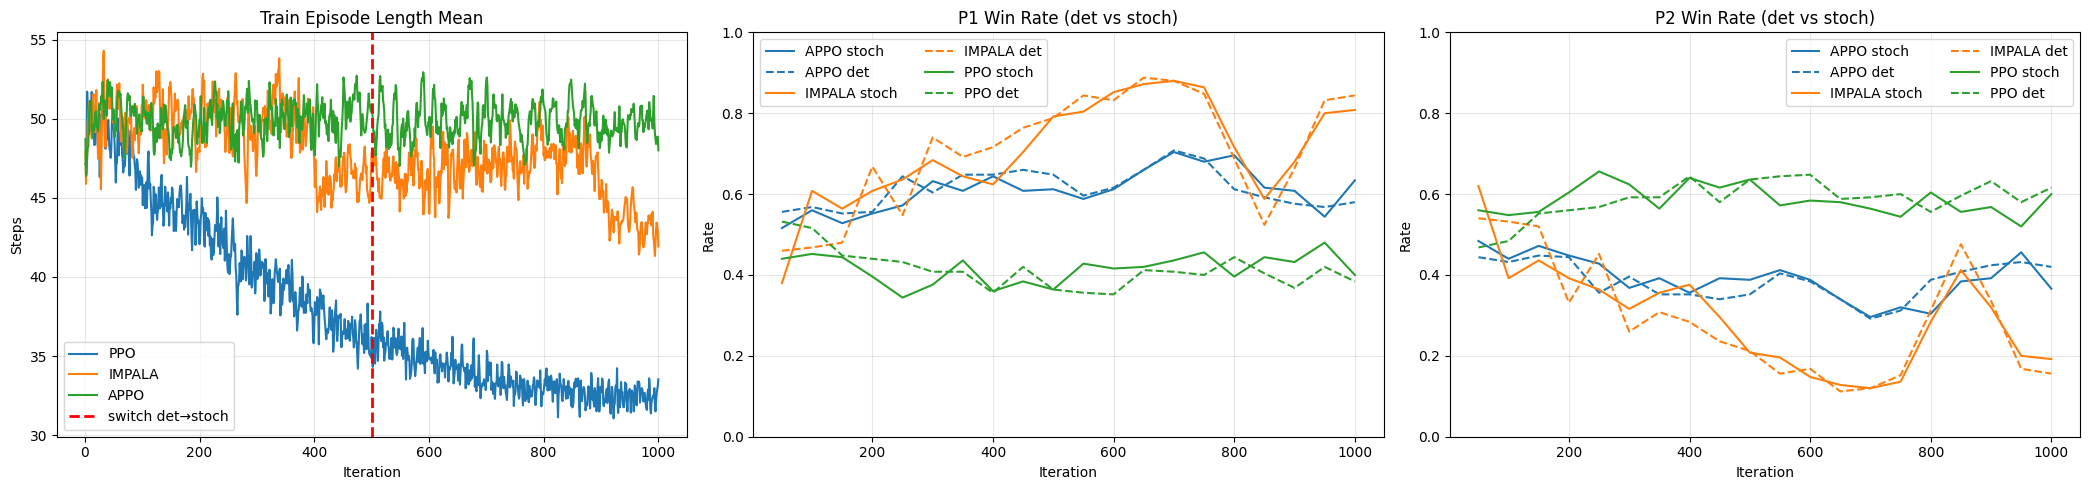

In [5]:
import re
import matplotlib.pyplot as plt


def evaluate_rllib(algo, n_episodes=80, seed=10000, stochastic_moves=True, accept_prob=0.5, opening_random_moves=0):
    env = SuperTicTacToeMultiAgentEnv(
        {
            "seed": int(seed),
            "stochastic_moves": bool(stochastic_moves),
            "accept_prob": float(accept_prob),
            "opening_random_moves": int(opening_random_moves),
        }
    )
    p1_wins = p2_wins = draws = 0
    for ep in range(int(n_episodes)):
        obs, _ = env.reset(seed=int(seed) + ep)
        terminated = {"__all__": False}
        truncated = {"__all__": False}
        ep_ret = {"player1": 0.0, "player2": 0.0}
        while (not terminated["__all__"]) and (not truncated["__all__"]):
            if not obs:
                break
            agent_id = next(iter(obs.keys()))
            a = algo.compute_single_action(obs[agent_id], policy_id=agent_id, explore=False)
            if isinstance(a, tuple):
                a = a[0]
            obs, rewards, terminated, truncated, _ = env.step({agent_id: int(a)})
            for k, v in rewards.items():
                ep_ret[k] = float(ep_ret.get(k, 0.0) + float(v))
        if ep_ret.get("player1", 0.0) > 0:
            p1_wins += 1
        elif ep_ret.get("player1", 0.0) < 0:
            p2_wins += 1
        else:
            draws += 1
    return {"p1_win": p1_wins / n_episodes, "p2_win": p2_wins / n_episodes, "draw": draws / n_episodes}


def apply_common_config(config):
    if hasattr(config, "api_stack"):
        try:
            config = config.api_stack(enable_rl_module_and_learner=False, enable_env_runner_and_connector_v2=False)
        except TypeError:
            try:
                config = config.api_stack(enable_rl_module_and_learner=False)
            except Exception:
                pass

    if hasattr(config, "env_runners"):
        try:
            config = config.env_runners(num_env_runners=0)
        except TypeError:
            config = config.env_runners(num_rollout_workers=0)
    else:
        config = config.rollouts(num_rollout_workers=0)

    config = config.resources(num_gpus=int(NUM_GPUS))
    config = config.multi_agent(
        policies=policies,
        policy_mapping_fn=lambda agent_id, *args, **kwargs: agent_id,
        policies_to_train=["player1", "player2"],
    )
    return config


def robust_training_config(config, kwargs):
    local_kwargs = dict(kwargs)
    while True:
        try:
            return config.training(**local_kwargs)
        except TypeError as e:
            m = re.search(r"unexpected keyword argument '([^']+)'", str(e))
            if not m:
                raise
            local_kwargs.pop(m.group(1), None)
            if not local_kwargs:
                raise


def build_rllib_configs(seed=0):
    algos = {}
    from ray.rllib.algorithms.ppo import PPOConfig
    ppo = PPOConfig().environment(
        env="super_ttt_ma_bench",
        env_config={
            "seed": int(seed),
            "stochastic_moves": False,
            "accept_prob": 1.0,
            "opening_random_moves": int(OPENING_RANDOM_MOVES_TRAIN),
        },
    ).framework("torch")
    if hasattr(ppo, "debugging"):
        try:
            ppo = ppo.debugging(seed=int(seed))
        except TypeError:
            pass
    ppo = apply_common_config(ppo)
    ppo = robust_training_config(
        ppo,
        {"gamma": 0.99, "lr": 3e-4, "train_batch_size": 2048, "sgd_minibatch_size": 64, "num_sgd_iter": 10, "minibatch_size": 64, "num_epochs": 10},
    )
    algos["PPO"] = ppo

    from ray.rllib.algorithms.impala import ImpalaConfig
    impala = ImpalaConfig().environment(
        env="super_ttt_ma_bench",
        env_config={
            "seed": int(seed),
            "stochastic_moves": False,
            "accept_prob": 1.0,
            "opening_random_moves": int(OPENING_RANDOM_MOVES_TRAIN),
        },
    ).framework("torch")
    if hasattr(impala, "debugging"):
        try:
            impala = impala.debugging(seed=int(seed))
        except TypeError:
            pass
    impala = apply_common_config(impala)
    impala = robust_training_config(impala, {"gamma": 0.99, "lr": 3e-4, "train_batch_size": 1024, "rollout_fragment_length": 50})
    algos["IMPALA"] = impala

    from ray.rllib.algorithms.appo import APPOConfig
    appo = APPOConfig().environment(
        env="super_ttt_ma_bench",
        env_config={
            "seed": int(seed),
            "stochastic_moves": False,
            "accept_prob": 1.0,
            "opening_random_moves": int(OPENING_RANDOM_MOVES_TRAIN),
        },
    ).framework("torch")
    if hasattr(appo, "debugging"):
        try:
            appo = appo.debugging(seed=int(seed))
        except TypeError:
            pass
    appo = apply_common_config(appo)
    appo = robust_training_config(appo, {"gamma": 0.99, "lr": 2e-4, "train_batch_size": 1024, "rollout_fragment_length": 50})
    algos["APPO"] = appo

    return algos


def _set_env_mode(env, stochastic_moves: bool, accept_prob: float):
    try:
        env.set_mode(stochastic_moves=stochastic_moves, accept_prob=accept_prob)
        return
    except Exception:
        pass
    try:
        env.stochastic_moves = bool(stochastic_moves)
        env.accept_prob = float(accept_prob)
    except Exception:
        pass


def _switch_algo_envs(algo, stochastic_moves: bool, accept_prob: float):
    try:
        algo.workers.foreach_worker(lambda w: w.foreach_env(lambda e: _set_env_mode(e, stochastic_moves, accept_prob)))
        return
    except Exception:
        pass
    try:
        algo.workers.local_worker().foreach_env(lambda e: _set_env_mode(e, stochastic_moves, accept_prob))
    except Exception:
        pass


def train_rllib_variant(name, cfg, iters=200, eval_every=20, n_eval_episodes=80, final_eval_episodes=100):
    algo = None
    train_len_mean = []
    eval_rows = []
    try:
        tqdm.write(f"{name}: building ...")
        t_build0 = time.time()
        algo = cfg.build_algo() if hasattr(cfg, "build_algo") else cfg.build()
        t_build = time.time() - t_build0
        tqdm.write(f"{name}: built in {t_build:.1f}s")

        switch_it = int(max(1, round(TRAIN_DET_FRAC * float(iters))))
        switched = False

        for it in tqdm(range(1, int(iters) + 1), desc=f"{name} train"):
            if (not switched) and it == switch_it:
                _switch_algo_envs(algo, stochastic_moves=True, accept_prob=float(TRAIN_STOCH_ACCEPT_PROB))
                switched = True

            t0 = time.time()
            res = algo.train()
            t_train = time.time() - t0
            mean_len = res.get("env_runners", {}).get("episode_len_mean", res.get("episode_len_mean", 0.0))
            train_len_mean.append(float(mean_len))

            do_eval = (it % int(eval_every) == 0) or (it == int(iters))
            if not do_eval:
                continue

            n_eps = int(final_eval_episodes if it == int(iters) else n_eval_episodes)
            t1 = time.time()
            det = evaluate_rllib(
                algo,
                n_episodes=n_eps,
                seed=10000 + it,
                stochastic_moves=False,
                accept_prob=float(EVAL_DET_ACCEPT_PROB),
                opening_random_moves=int(OPENING_RANDOM_MOVES_EVAL),
            )
            stoch = evaluate_rllib(
                algo,
                n_episodes=n_eps,
                seed=20000 + it,
                stochastic_moves=True,
                accept_prob=float(EVAL_STOCH_ACCEPT_PROB),
                opening_random_moves=int(OPENING_RANDOM_MOVES_EVAL),
            )
            t_eval = time.time() - t1

            row = {
                "algo": name,
                "iter": int(it),
                "train_s": float(t_train),
                "eval_s": float(t_eval),
                "train_len_mean": float(mean_len),
                "det_p1": float(det["p1_win"]),
                "det_p2": float(det["p2_win"]),
                "det_draw": float(det["draw"]),
                "stoch_p1": float(stoch["p1_win"]),
                "stoch_p2": float(stoch["p2_win"]),
                "stoch_draw": float(stoch["draw"]),
            }
            eval_rows.append(row)
            tqdm.write(
                f"{name} it={it:04d} len={mean_len:.1f} det_p1={row['det_p1']:.3f} stoch_p1={row['stoch_p1']:.3f}"
            )
    finally:
        if algo is not None:
            try:
                algo.stop()
            except Exception:
                pass
    return {"train_len_mean": train_len_mean, "eval_rows": eval_rows}


rllib_configs = build_rllib_configs(seed=SEED)

selected = [a for a in ALGOS_TO_RUN if a in rllib_configs]
benchmark = {}

for name in selected:
    benchmark[name] = train_rllib_variant(
        name,
        rllib_configs[name],
        iters=ITERS,
        eval_every=EVAL_EVERY,
        n_eval_episodes=EVAL_EPISODES,
        final_eval_episodes=FINAL_EVAL_EPISODES,
    )

rows = []
for algo_name, pack in benchmark.items():
    rows.extend(pack["eval_rows"])

df = pd.DataFrame(rows).sort_values(["algo", "iter"]).reset_index(drop=True)
display(df)

df_final = df.sort_values(["algo", "iter"]).groupby("algo", as_index=False).tail(1).reset_index(drop=True)
display(df_final)

switch_x = int(max(1, round(TRAIN_DET_FRAC * float(ITERS))))

fig, ax = plt.subplots(1, 3, figsize=(21, 5))

for algo_name, pack in benchmark.items():
    ax[0].plot(range(1, len(pack["train_len_mean"]) + 1), pack["train_len_mean"], label=algo_name)
ax[0].axvline(x=switch_x, color="red", linestyle="--", linewidth=2, label="switch det→stoch")
ax[0].set_title("Train Episode Length Mean")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Steps")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

for algo_name, g in df.groupby("algo"):
    line_stoch, = ax[1].plot(g["iter"], g["stoch_p1"], linestyle="-", label=f"{algo_name} stoch")
    ax[1].plot(g["iter"], g["det_p1"], linestyle="--", color=line_stoch.get_color(), label=f"{algo_name} det")
ax[1].set_title("P1 Win Rate (det vs stoch)")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Rate")
ax[1].set_ylim(0, 1)
ax[1].grid(True, alpha=0.3)
ax[1].legend(ncol=2)

for algo_name, g in df.groupby("algo"):
    line_stoch, = ax[2].plot(g["iter"], g["stoch_p2"], linestyle="-", label=f"{algo_name} stoch")
    ax[2].plot(g["iter"], g["det_p2"], linestyle="--", color=line_stoch.get_color(), label=f"{algo_name} det")
ax[2].set_title("P2 Win Rate (det vs stoch)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("Rate")
ax[2].set_ylim(0, 1)
ax[2].grid(True, alpha=0.3)
ax[2].legend(ncol=2)

plt.tight_layout()
plt.show()


In [6]:
df.to_csv('train_details.csv', index=False)

In [7]:
df_final.to_csv('train_overall.csv', index=False)